In [243]:
import numpy as np
from z_test_cpd import ZTestCPDetector
from cusum import CusumMeanDetector
import os
import pandas as pd
from typing import List,Tuple
import matplotlib.pyplot as plt
import torch
from scipy import stats

In [244]:
DATASET_PATH = "../dataset"
INDEX_FIELD = "timestamp"
DATA_FIELD = "num_request"

In [245]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [246]:
def read_dataset(csv_path: str,index_field:str,data_field:str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path)
    return df[index_field].to_numpy(), df[data_field].to_numpy()

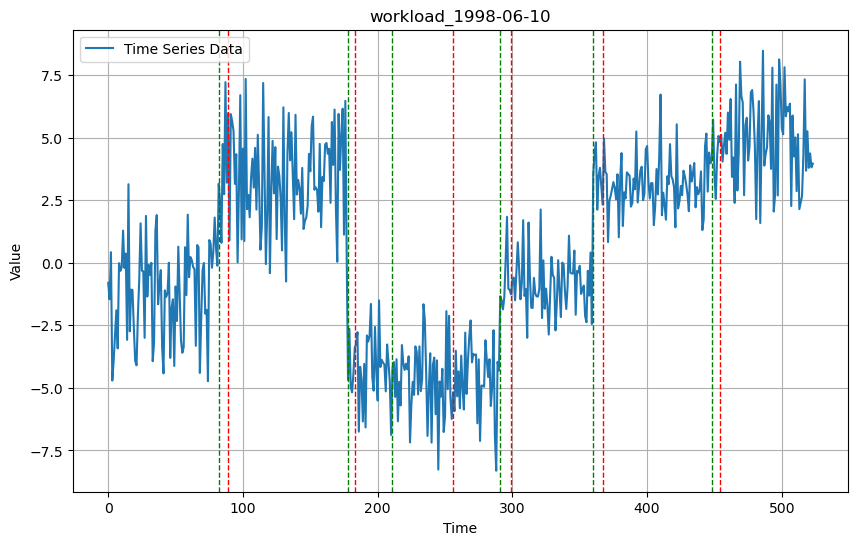

In [247]:
data_file_list = get_data_file_list(DATASET_PATH)
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    # np_index, np_data = read_dataset(os.path.join(DATASET_PATH, file_name), INDEX_FIELD, DATA_FIELD)
    segment_lengths = [np.random.randint(30,100) for _ in range(7)]
    np_data=np.concatenate([np.random.normal(np.random.uniform(-5,5),np.random.uniform()+1,seg_len) for seg_len in segment_lengths])
    # np_data = np.concatenate([np.random.normal(-5, 1, 30), np.random.normal(-2, 1, 30),np.random.normal(-3, 1, 30),np.random.normal(-1, 1, 30),np.random.normal(1, 1, 30),np.random.normal(3, 1, 30)])
    t_test_detector = ZTestCPDetector(20, 0.01)
    # t_test_detector=CusumMeanDetector(20,0.01)
    change_idx = []
    for idx, x in enumerate(np_data):
        _, is_change = t_test_detector.predict_next(x)
        # _, is_change = t_test_detector.predict_next(torch.tensor(x))
        if is_change:
            change_idx.append(idx)
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(np_data)), np_data, label='Time Series Data')
    for cp in change_idx:
        plt.axvline(x=cp, color='red', linestyle='--', linewidth=1)
    for seg in np.cumsum(segment_lengths)[:-1]:
        plt.axvline(x=seg, color='green', linestyle='--', linewidth=1)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(workload_name)
    plt.legend()
    plt.grid(True)
    plt.show()
    break

In [248]:
x=np.linspace(-5,5,1000)
y_1=np.array([torch.distributions.Normal(0,1).cdf(torch.abs(torch.tensor(xx))).item() for xx in x])
y_2=np.array([stats.norm.cdf(np.abs(xx),loc=0,scale=1) for xx in x])

In [249]:
print(np.sum(y_1-y_2))

-3.9968028886505635e-15


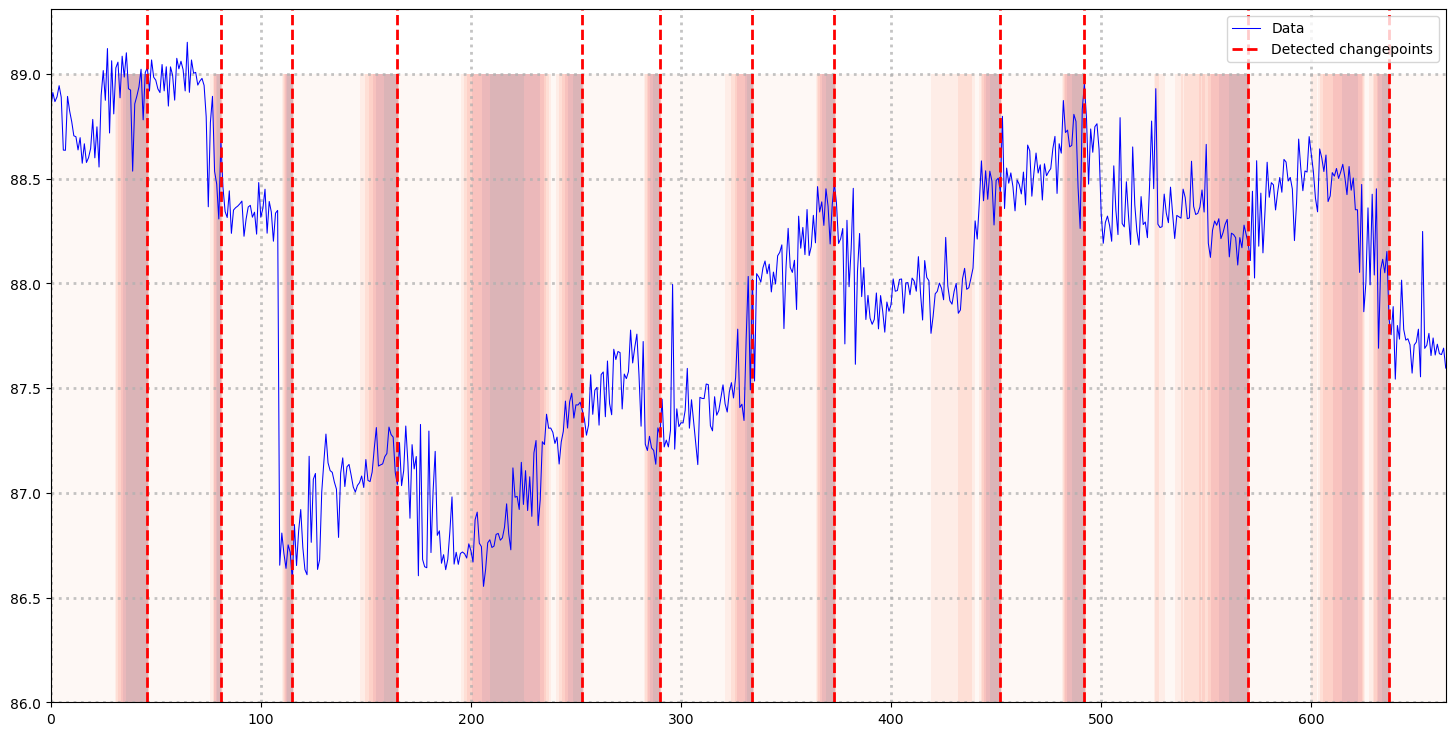

In [250]:
import pandas as pd
df = pd.read_csv("SKAB/other/11.csv",sep=";")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")
y = df.iloc[:,5].values
test = ZTestCPDetector()
outs = [test.predict_next(y[i]) for i in range(len(y))]
cps = np.where(list(map(lambda x: x[1], outs)))[0]
probs = np.array(list(map(lambda x: x[0], outs)))
X, Y = np.meshgrid(np.arange(len(y)),np.linspace(int(np.min(y)),int(np.max(y))))
Z = probs[X]
plt.figure(figsize=(18,9))
plt.contourf(X,Y,Z,alpha=0.3,cmap="Reds")
plt.plot(np.arange(len(y)),y,lw=0.75,label="Data",color="blue")
plt.axvline(cps[0], color="red", linestyle="dashed",label="Detected changepoints",lw=2)
[plt.axvline(cp, color="red", linestyle="dashed",lw=2) for cp in cps[1:]]
plt.grid(alpha=0.75, linestyle="dotted",lw=2)
plt.legend()